Import thư viện

In [1]:
!pip install rdkit-pypi networkx pandas numpy scikit-learn imbalanced-learn matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Thư viện Hóa tin học RDKit
from rdkit import Chem
from rdkit.Chem import Draw

# Thư viện Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("Đã import thành công các thư viện cho dự án Drug Discovery!")

Đã import thành công các thư viện cho dự án Drug Discovery!


Load dữu liệu và EDA

In [3]:
df = pd.read_csv('tox21.csv')
display(df.head(5))

# Hiển thị thông tin tổng quan để xem có bao nhiêu cột numeric, bao nhiêu cột object
print("\nThông tin bộ dữ liệu:")
df.info()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O



Thông tin bộ dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7265 non-null   float64
 1   NR-AR-LBD      6758 non-null   float64
 2   NR-AhR         6549 non-null   float64
 3   NR-Aromatase   5821 non-null   float64
 4   NR-ER          6193 non-null   float64
 5   NR-ER-LBD      6955 non-null   float64
 6   NR-PPAR-gamma  6450 non-null   float64
 7   SR-ARE         5832 non-null   float64
 8   SR-ATAD5       7072 non-null   float64
 9   SR-HSE         6467 non-null   float64
 10  SR-MMP         5810 non-null   float64
 11  SR-p53         6774 non-null   float64
 12  mol_id         7831 non-null   object 
 13  smiles         7831 non-null   object 
dtypes: float64(12), object(2)
memory usage: 856.6+ KB


Số lượng giá trị thiếu trong từng cột:
smiles       0
SR-p53    1057
dtype: int64


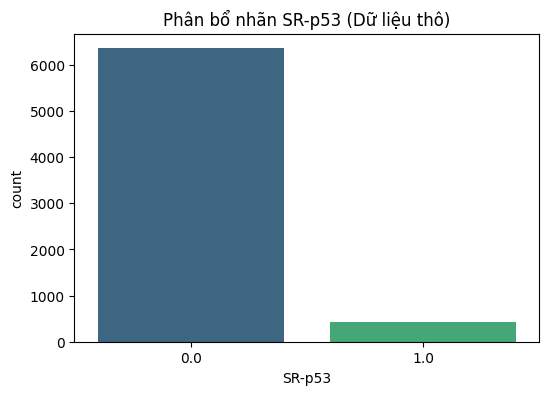

Ví dụ 5 dòng SMILES đầu tiên:


0                         CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1                            CCN1C(=O)NC(c2ccccc2)C1=O
2    CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3                      CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4                            CC(O)(P(=O)(O)O)P(=O)(O)O
Name: smiles, dtype: object

In [4]:
# 1. Kiểm tra giá trị thiếu (NaN)
print("Số lượng giá trị thiếu trong từng cột:")
print(df[['smiles', 'SR-p53']].isnull().sum())

# 2. Kiểm tra phân bổ nhãn (trước khi lọc)
plt.figure(figsize=(6, 4))
sns.countplot(x='SR-p53', data=df, palette='viridis')
plt.title('Phân bổ nhãn SR-p53 (Dữ liệu thô)')
plt.show()

# 3. Xem thử một vài cấu trúc SMILES thô
print("Ví dụ 5 dòng SMILES đầu tiên:")
display(df['smiles'].head())

Tiền xử lý

In [5]:
target_col = 'SR-p53'
df = df.dropna(subset=[target_col, 'smiles']).reset_index(drop=True)

# Chuyển SMILES thành đối tượng RDKit Mol
raw_mols = [Chem.MolFromSmiles(s) for s in df['smiles']]
raw_labels = df[target_col].values

# Lọc bỏ các phân tử bị lỗi (None) sinh ra trong quá trình chuyển đổi
valid_indices = [i for i, m in enumerate(raw_mols) if m is not None]
mols = [raw_mols[i] for i in valid_indices]
y_labels = raw_labels[valid_indices]

print(f"Tổng số phân tử hợp lệ: {len(mols)}")

[21:47:19] WARNING: not removing hydrogen atom without neighbors


Tổng số phân tử hợp lệ: 6774


Thuật toán Frequent Subgraph Mining (FSM)

In [6]:
def fsm_algorithm(dataset_mols, min_sup_threshold, max_k=6):
    total_mols = len(dataset_mols)
    min_sup_count = int(min_sup_threshold * total_mols)
    final_frequent_subgraphs = []
    
    print(f"Bắt đầu FSM với min_sup = {min_sup_threshold} (Cần xuất hiện ít nhất trong {min_sup_count}/{total_mols} phân tử)")
    
    current_frequent_patterns = {} 
    initial_counts = defaultdict(int)
    initial_mols = {}
    
    for mol in dataset_mols:
        paths_1 = Chem.FindAllPathsOfLengthN(mol, 1, useBonds=True)
        for path in paths_1:
            amap = {}
            sub_mol = Chem.PathToSubmol(mol, path, atomMap=amap)
            can_smiles = Chem.MolToSmiles(sub_mol, canonical=True)
            
            initial_counts[can_smiles] += 1
            if can_smiles not in initial_mols:
                initial_mols[can_smiles] = sub_mol

    for smiles, count in initial_counts.items():
        if count >= min_sup_count and initial_mols[smiles] is not None:
            current_frequent_patterns[smiles] = initial_mols[smiles]
            final_frequent_subgraphs.append(initial_mols[smiles])

    k = 2 
    
    while len(current_frequent_patterns) > 0 and k <= max_k: 
        print(f"-> Đang khai phá các subgraph kích thước k = {k}...")
        candidates = {}
        
        for mol in dataset_mols:
            paths_k = Chem.FindAllPathsOfLengthN(mol, k, useBonds=True)
            for path in paths_k:
                amap = {}
                sub_mol = Chem.PathToSubmol(mol, path, atomMap=amap)
                can_smiles = Chem.MolToSmiles(sub_mol, canonical=True)
                
                if can_smiles not in candidates:
                    is_valid_candidate = False
                    for freq_smiles, freq_mol in current_frequent_patterns.items():
                        if sub_mol.HasSubstructMatch(freq_mol):
                            is_valid_candidate = True
                            break
                    
                    if is_valid_candidate:
                        candidates[can_smiles] = sub_mol
                    
        next_frequent_patterns = {}
        for can_smiles, can_mol in candidates.items():
            support_count = sum(1 for mol in dataset_mols if mol.HasSubstructMatch(can_mol))
            
            if support_count >= min_sup_count:
                next_frequent_patterns[can_smiles] = can_mol
                final_frequent_subgraphs.append(can_mol)
        
        current_frequent_patterns = next_frequent_patterns
        k += 1

    print(f"Hoàn thành FSM! Tổng số frequent subgraphs tìm được: {len(final_frequent_subgraphs)}")
    return final_frequent_subgraphs

Khai phá Đồ thị

In [7]:
# Lọc ra nhóm phân tử mang độc tính (Nhãn = 1) để tìm các mẫu gây độc (Toxicophores)
toxic_mols = [mols[i] for i in range(len(mols)) if y_labels[i] == 1]
print(f"Số lượng phân tử có độc tính tham gia khai phá: {len(toxic_mols)}")

# Cài đặt ngưỡng tối thiểu min_sup (0.1 = 10%)
min_sup = 0.1 

# Gọi hàm khai phá
discovered_patterns = fsm_algorithm(toxic_mols, min_sup_threshold=min_sup, max_k=6)

Số lượng phân tử có độc tính tham gia khai phá: 423
Bắt đầu FSM với min_sup = 0.1 (Cần xuất hiện ít nhất trong 42/423 phân tử)
-> Đang khai phá các subgraph kích thước k = 2...
-> Đang khai phá các subgraph kích thước k = 3...
-> Đang khai phá các subgraph kích thước k = 4...
-> Đang khai phá các subgraph kích thước k = 5...
-> Đang khai phá các subgraph kích thước k = 6...
Hoàn thành FSM! Tổng số frequent subgraphs tìm được: 398


Xây dựng Ma trận Đặc trưng và Cân bằng dữ liệu

In [8]:
print("Đang tạo Ma trận đặc trưng (Feature Matrix)...")

# Rút gọn bớt features nếu quá nhiều để tránh hiện tượng Overfitting
if len(discovered_patterns) > 200:
    discovered_patterns = discovered_patterns[-200:] 

# Biến đổi mỗi phân tử thành một vector nhị phân (1 nếu chứa subgraph, 0 nếu không)
X_features = []
for mol in mols:
    features = [1 if mol.HasSubstructMatch(p) else 0 for p in discovered_patterns]
    X_features.append(features)

X = np.array(X_features)
y = y_labels

print(f"Kích thước tập dữ liệu trước cân bằng: {X.shape}")

# Áp dụng thuật toán SMOTE để cân bằng số lượng mẫu độc/không độc
print("Đang xử lý mất cân bằng bằng SMOTE...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Kích thước tập dữ liệu sau cân bằng: {X_resampled.shape}")

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")


Đang tạo Ma trận đặc trưng (Feature Matrix)...
Kích thước tập dữ liệu trước cân bằng: (6774, 200)
Đang xử lý mất cân bằng bằng SMOTE...
Kích thước tập dữ liệu sau cân bằng: (12702, 200)
Kích thước tập huấn luyện: (10161, 200)
Kích thước tập kiểm tra: (2541, 200)


Huấn luyện mô hình Random Forest trên dữ liệu Subgraphs và đánh giá

,precision,recall,f1-score,AUC,support
0.0,0.833844,0.858156,0.845825,0.922000,1269.000000
1.0,0.854251,0.829403,0.841643,0.922000,1272.000000
accuracy,,,0.843762,0.922000,0.843762
macro avg,0.844047,0.843779,0.843734,0.922000,2541.000000
weighted avg,0.844059,0.843762,0.843732,0.922000,2541.000000


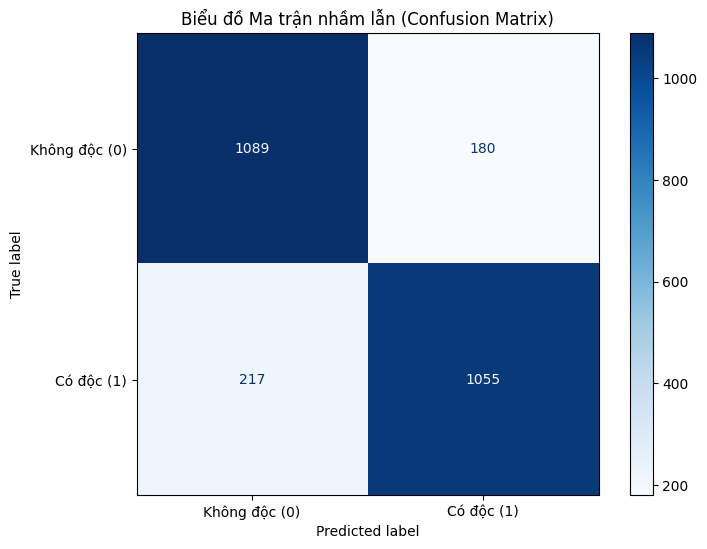

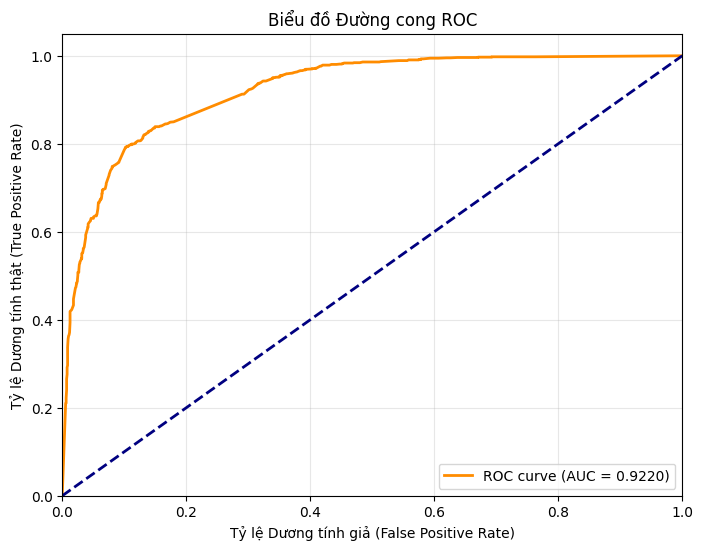


Top 5 cấu trúc con quyết định độc tính:


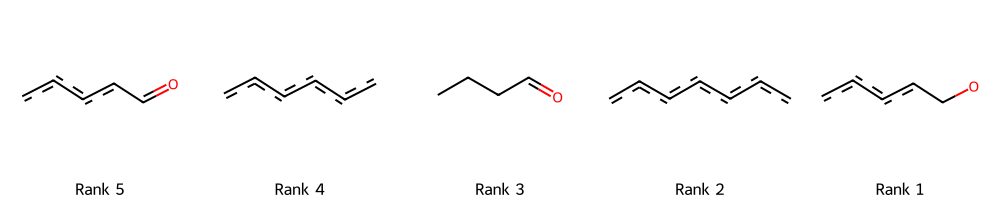

In [9]:
# 1. Huấn luyện Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. Dự đoán nhãn và xác suất
y_pred = rf.predict(X_test)
y_probs = rf.predict_proba(X_test)[:, 1]

# 3. Tính toán các chỉ số
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Tính AUC tổng thể
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
model_auc = auc(fpr, tpr)
report_df.insert(loc=3, column='AUC', value=model_auc)

report_df.at['accuracy', 'precision'] = ""
report_df.at['accuracy', 'recall'] = ""

# Trình bày trực quan bằng đường kẻ
styled_report = report_df.style.set_properties(**{'border': '1px solid black', 'text-align': 'center'})\
.set_table_styles([{'selector': 'th', 'props': [('border', '1px solid black'), ('background-color','1px solid black')]}])
display(styled_report)

# 5. Vẽ Confusion Matrix dạng biểu đồ Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Không độc (0)', 'Có độc (1)'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Biểu đồ Ma trận nhầm lẫn (Confusion Matrix)')
plt.show()

# 6. Vẽ biểu đồ ROC Curve và hiển thị AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {model_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)')
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)')
plt.title('Biểu đồ Đường cong ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 7. Trực quan hóa các mảnh cấu trúc quan trọng nhất (Toxicophores)
importances = rf.feature_importances_
top_indices = np.argsort(importances)[-5:]

print("\nTop 5 cấu trúc con quyết định độc tính:")
top_mols = [discovered_patterns[i] for i in top_indices]
img = Draw.MolsToGridImage(top_mols, molsPerRow=5, legends=[f"Rank {5-i}" for i in range(5)])
display(img)